# Compare Jnkep model and Petigura2020 model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import matplotlib

In [2]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/k2-19-project/data


In [3]:
### Define data directory
# data_dir = "/Users/pentrican10/Projects/Data/k2-19-data"

TESS_offset = 2457000
petigura_offset = 2454833

In [4]:
### get data from jnkepler fit
import json

# Load the data from the JSON file
with open("data/jnkep_fit_data.json", "r") as f:
    data = json.load(f)
# Access values just like a dictionary
# t_jnkep_b = data["jnkep_model_times"]["b"]
# t_jnkep_c = data["jnkep_model_times"]["c"]

t_obs_b = data["jnkep_observed_times"]["b"]
t_obs_c = data["jnkep_observed_times"]["c"]

t_obs_err_b = data["jnkep_observed_times_err"]["b"]
t_obs_err_c = data["jnkep_observed_times_err"]["c"]

index_obs_b = data["jnkep_observed_index"]["b"]
index_obs_c = data["jnkep_observed_index"]["c"]

best_fit_period_b = data["best_fit_params"]["period"]["b"]
best_fit_period_c = data["best_fit_params"]["period"]["c"]

best_fit_tc_b = data["best_fit_params"]["tc"]["b"]
best_fit_tc_c = data["best_fit_params"]["tc"]["c"]


In [5]:

# Load the data from the JSON file
with open("data/jnkep_mcmc_data.json", "r") as f:
    data_mcmc = json.load(f)
# Access values just like a dictionary
t_jnkep_b = data_mcmc["jnkep_mcmc_times"]["b"]
t_jnkep_c = data_mcmc["jnkep_mcmc_times"]["c"]

t_jnkep_err_b = data_mcmc["jnkep_mcmc_times_err"]["b"]
t_jnkep_err_c = data_mcmc["jnkep_mcmc_times_err"]["c"]


In [6]:
# Load the data from the JSON file
with open("data/jnkep_mcmc_data_extrapolate.json", "r") as f:
    data_mcmc = json.load(f)
# Access values just like a dictionary
t_jnkep_b = data_mcmc["jnkep_mcmc_times_ext"]["b"]
t_jnkep_c = data_mcmc["jnkep_mcmc_times_ext"]["c"]

t_jnkep_err_b = data_mcmc["jnkep_mcmc_times_ext_err"]["b"]
t_jnkep_err_c = data_mcmc["jnkep_mcmc_times_ext_err"]["c"]


In [7]:
def ephem(p,tc,ind):
    t = tc + (p*ind)
    return t

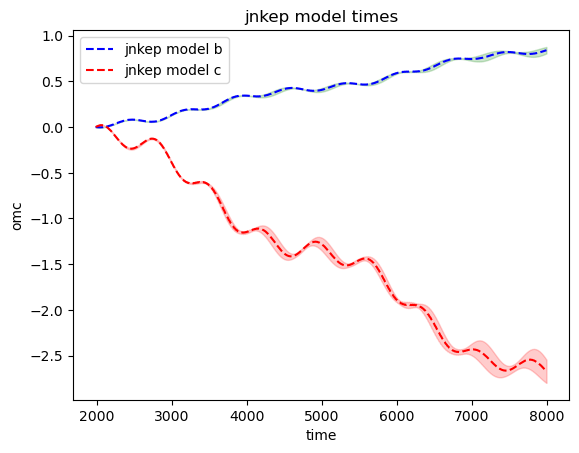

In [8]:
### plot the jnkep model
ind_jnkep_b = np.arange(0,(len(np.array(t_jnkep_b))), 1)
ind_jnkep_c = np.arange(0,(len(np.array(t_jnkep_c))), 1)

jnkep_ephem_time_b = ephem(best_fit_period_b, best_fit_tc_b, ind_jnkep_b)
jnkep_ephem_time_c = ephem(best_fit_period_c, best_fit_tc_c, ind_jnkep_c)

jnkep_omc_b = t_jnkep_b - jnkep_ephem_time_b
jnkep_omc_c = t_jnkep_c - jnkep_ephem_time_c

# plt.plot(t_jnkep_b, jnkep_omc_b, label='jnkep model b', c='g')
# plt.plot(t_jnkep_c, jnkep_omc_c, label='jnkep model c', c='r')

# Plotting
plt.plot(t_jnkep_b, jnkep_omc_b, label='jnkep model b', linestyle='--', color='b')
plt.fill_between(t_jnkep_b,
                 jnkep_omc_b - t_jnkep_err_b,
                 jnkep_omc_b + t_jnkep_err_b,
                 color='g', alpha=0.2)

plt.plot(t_jnkep_c, jnkep_omc_c, label='jnkep model c', linestyle='--', color='r')
plt.fill_between(t_jnkep_c,
                 jnkep_omc_c - t_jnkep_err_c,
                 jnkep_omc_c + t_jnkep_err_c,
                 color='r', alpha=0.2)

plt.title('jnkep model times')
plt.xlabel('time')
plt.ylabel('omc')
plt.legend()
plt.show()

In [9]:
### Predicted times from Petigura2020
file_petigura_predicted_time = 'ajab5220t4_mrt.txt'
def read_table(file_name):
    ### path to table - Petigura et al 2020
    file_path = os.path.join(data_dir, file_name)

    ### Define the column names 
    columns = ["Planet", "Transit","Date", "Tc_pred", "e_Tc_pred"]

    ### Read the text file, specifying space as the delimiter, skipping model_guess_omc rows
    df = pd.read_csv(file_path, delim_whitespace=True, skiprows=17, names=columns)

    ### Remove NaN values
    df = df.dropna()
    return df

df_petigura_mod = read_table(file_petigura_predicted_time)

### separate by planet
df_petigura_b = df_petigura_mod[df_petigura_mod["Planet"] == 'b']
print(df_petigura_b)
df_petigura_c = df_petigura_mod[df_petigura_mod["Planet"] == 'c']

# Filter for times < 5500
df_petigura_b = df_petigura_b[df_petigura_b["Tc_pred"] < 5500]
df_petigura_c = df_petigura_c[df_petigura_c["Tc_pred"] < 5500]

     Planet  Transit        Date    Tc_pred  e_Tc_pred
0         b        0  2014-06-04  1980.3840     0.0002
2         b        1  2014-06-12  1988.3041     0.0002
4         b        2  2014-06-20  1996.2220     0.0002
5         b        3  2014-06-28  2004.1406     0.0002
7         b        4  2014-07-06  2012.0614     0.0001
...     ...      ...         ...        ...        ...
1189      b      714  2029-11-28  7635.6831     0.0496
1191      b      715  2029-12-06  7643.6031     0.0480
1193      b      716  2029-12-14  7651.5243     0.0468
1194      b      717  2029-12-21  7659.4466     0.0446
1196      b      718  2029-12-29  7667.3662     0.0434

[719 rows x 5 columns]


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_93078/3011789988.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, skiprows=17, names=columns)


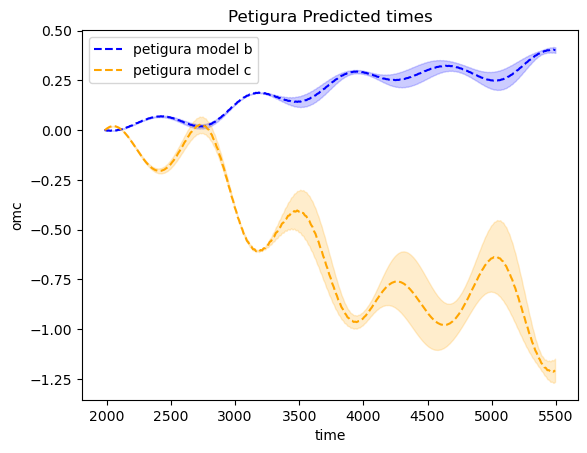

In [10]:
### best fit periods and tc
# best_fit_periods = popt['period']
# best_fit_tc = popt['tic']
# period_b_fit =  best_fit_periods[0]
# period_c_fit = best_fit_periods[1]
# tc_b_fit = best_fit_tc[0]
# tc_c_fit = best_fit_tc[1]

def ephem(p,tc,ind):
    t = tc + (p*ind)
    return t
    
ind_petigura_b = df_petigura_b["Transit"]
ind_petigura_c = df_petigura_c["Transit"]

t_petigura_b = df_petigura_b["Tc_pred"]
t_petigura_c = df_petigura_c["Tc_pred"]

t_err_petigura_b = df_petigura_b["e_Tc_pred"]
t_err_petigura_c = df_petigura_c["e_Tc_pred"]

ephem_time_b = ephem(best_fit_period_b, best_fit_tc_b, ind_petigura_b)
ephem_time_c = ephem(best_fit_period_c, best_fit_tc_c, ind_petigura_c)

ephem_omc_b = t_petigura_b - ephem_time_b
ephem_omc_c = t_petigura_c - ephem_time_c

# times = df_petigura_mod["Tc_pred"]
# plt.plot(t_petigura_b, ephem_omc_b, label='petigura model b',linestyle='--',c='b')
# plt.plot(t_petigura_c, ephem_omc_c, label='petigura model c',linestyle='--',c='orange')
# Plotting with error bars
# plt.errorbar(t_petigura_b, ephem_omc_b, yerr=t_err_petigura_b, label='petigura model b', linestyle='--', c='b')
# plt.errorbar(t_petigura_c, ephem_omc_c, yerr=t_err_petigura_c, label='petigura model c', linestyle='--', c='orange')

# Plotting
plt.plot(t_petigura_b, ephem_omc_b, label='petigura model b', linestyle='--', color='b')
plt.fill_between(t_petigura_b,
                 ephem_omc_b - t_err_petigura_b,
                 ephem_omc_b + t_err_petigura_b,
                 color='b', alpha=0.2)

plt.plot(t_petigura_c, ephem_omc_c, label='petigura model c', linestyle='--', color='orange')
plt.fill_between(t_petigura_c,
                 ephem_omc_c - t_err_petigura_c,
                 ephem_omc_c + t_err_petigura_c,
                 color='orange', alpha=0.2)

plt.title('Petigura Predicted times')
plt.xlabel('time')
plt.ylabel('omc')
plt.legend()
plt.show()

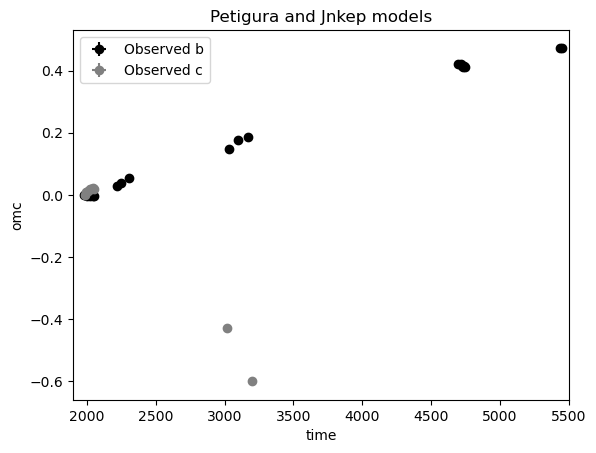

In [13]:
### adding observed data
### same ephem as the model and predictions 
index_obs_b = np.array(index_obs_b)
index_obs_c = np.array(index_obs_c)
omc_obs_b = t_obs_b - ephem(best_fit_period_b, best_fit_tc_b, index_obs_b)
omc_obs_c = t_obs_c - ephem(best_fit_period_c, best_fit_tc_c, index_obs_c)
offset_obs_b = omc_obs_b[0]
offset_obs_c = omc_obs_c[0]

plt.errorbar(t_obs_b, omc_obs_b - offset_obs_b, xerr=t_obs_err_b, yerr=t_obs_err_b, marker='o', linestyle='none', label='Observed b', c='black')
plt.errorbar(t_obs_c, omc_obs_c - offset_obs_c, xerr=t_obs_err_c, yerr=t_obs_err_c, marker='o', linestyle='none', label='Observed c', c='grey')

plt.title('Petigura and Jnkep models')
plt.xlabel('time')
plt.ylabel('omc')
# plt.xlim(2027.88,2027.92)
plt.xlim(1900,5500)

plt.legend()
plt.show()

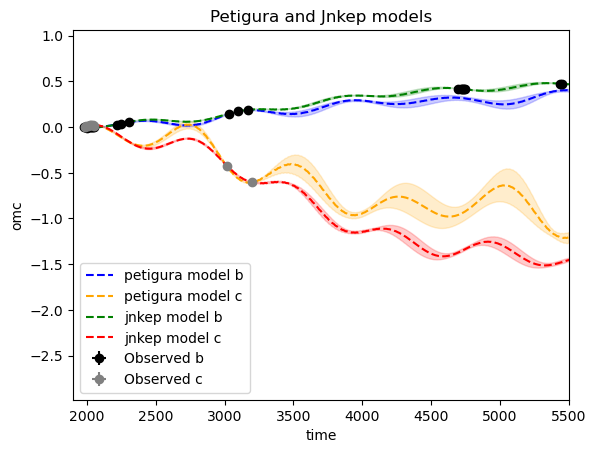

In [14]:
### adding observed data
### same ephem as the model and predictions 
# index_obs_b = np.array(index_obs_b)
# index_obs_c = np.array(index_obs_c)
# omc_obs_b = t_obs_b - ephem(best_fit_period_b, best_fit_tc_b, index_obs_b)
# omc_obs_c = t_obs_c - ephem(best_fit_period_c, best_fit_tc_c, index_obs_c)


# plt.scatter(t_obs_b, obs_omc_b, label='obs b')
# plt.scatter(t_obs_c, obs_omc_c, label='obs c')
# plt.plot(t_petigura_b, ephem_omc_b, label='petigura model b', linestyle='--',c='b')
# plt.plot(t_petigura_c, ephem_omc_c, label='petigura model c',linestyle='--',c='orange')
# Plotting
plt.plot(t_petigura_b, ephem_omc_b, label='petigura model b', linestyle='--', color='b')
plt.fill_between(t_petigura_b,
                 ephem_omc_b - t_err_petigura_b,
                 ephem_omc_b + t_err_petigura_b,
                 color='b', alpha=0.2)

plt.plot(t_petigura_c, ephem_omc_c, label='petigura model c', linestyle='--', color='orange')
plt.fill_between(t_petigura_c,
                 ephem_omc_c - t_err_petigura_c,
                 ephem_omc_c + t_err_petigura_c,
                 color='orange', alpha=0.2)

# plt.plot(t_jnkep_b, jnkep_omc_b, label='jnkep model b',c='g')
# plt.plot(t_jnkep_c, jnkep_omc_c, label='jnkep model c',c='r')
plt.plot(t_jnkep_b, jnkep_omc_b, label='jnkep model b', linestyle='--', color='g')
plt.fill_between(t_jnkep_b,
                 jnkep_omc_b - t_jnkep_err_b,
                 jnkep_omc_b + t_jnkep_err_b,
                 color='g', alpha=0.2)

plt.plot(t_jnkep_c, jnkep_omc_c, label='jnkep model c', linestyle='--', color='r')
plt.fill_between(t_jnkep_c,
                 jnkep_omc_c - t_jnkep_err_c,
                 jnkep_omc_c + t_jnkep_err_c,
                 color='r', alpha=0.2)


offset_obs_b = omc_obs_b[0]
offset_obs_c = omc_obs_c[0]
# plt.scatter(t_obs_b, omc_obs_b-offset_obs_b,marker='o',label='Observed b',c='black')
# plt.scatter(t_obs_c, omc_obs_c-offset_obs_c, marker='o', label='Observed c',c='grey')
plt.errorbar(t_obs_b, omc_obs_b - offset_obs_b, xerr=t_obs_err_b, yerr=t_obs_err_b, marker='o', linestyle='none', label='Observed b', c='black')
plt.errorbar(t_obs_c, omc_obs_c - offset_obs_c, xerr=t_obs_err_c, yerr=t_obs_err_c, marker='o', linestyle='none', label='Observed c', c='grey')

plt.title('Petigura and Jnkep models')
plt.xlabel('time')
plt.ylabel('omc')
plt.xlim(1900,5500)
plt.legend()
plt.show()

In [15]:
# Use a linear fit (degree=1) to get slope and intercept
b_coeffs = np.polyfit(t_jnkep_b, jnkep_omc_b, 1)
b_slope = b_coeffs[0]
print(f'b slope for jnkep model (from linear fit): {b_slope}')
print(b_coeffs)
c_coeffs = np.polyfit(t_jnkep_c, jnkep_omc_c, 1)
c_slope = c_coeffs[0]
print(f'c slope for jnkep model (from linear fit): {c_slope}')

b slope for jnkep model (from linear fit): 0.00014559971406810003
[ 1.45599714e-04 -2.87836519e-01]
c slope for jnkep model (from linear fit): -0.00047336817919827227


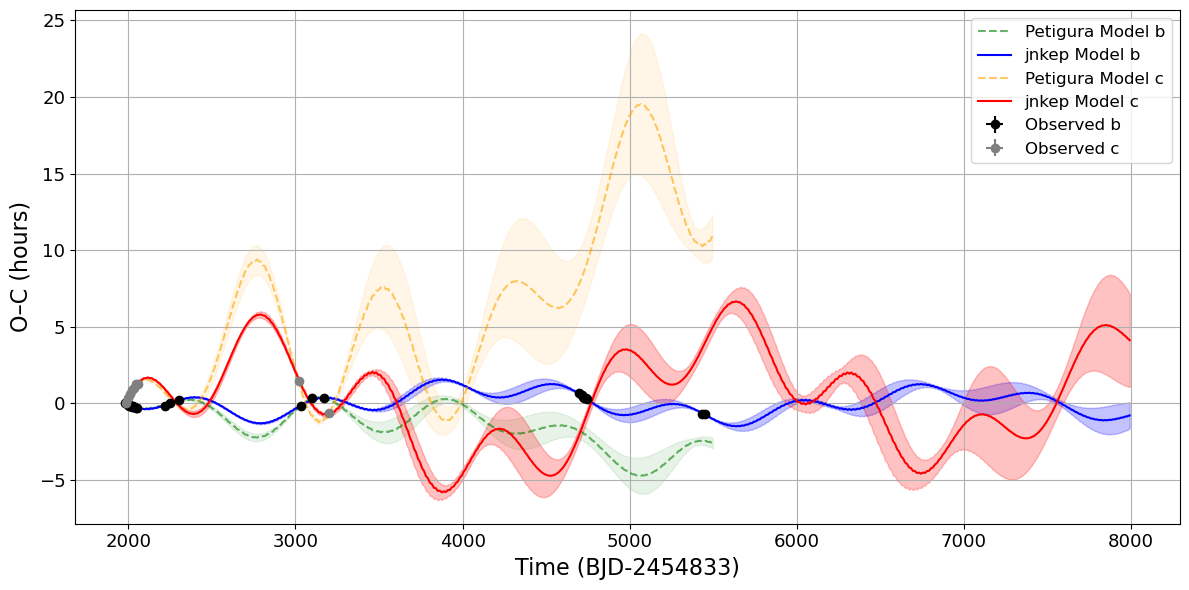

In [16]:
### Fit the linear trend for b and c (using numpy.polyfit)
def apply_trend(t, y, slope):
    # Ensure t and y are NumPy arrays
    t = np.asarray(t)
    y = np.asarray(y)
    # Remove slope, pivot about the first point
    return y - slope * (t - t[0])

### Planet b - Flatten the data
flat_petigura_b = apply_trend(t_petigura_b, ephem_omc_b, b_slope)
flat_jnkep_b = apply_trend(t_jnkep_b, jnkep_omc_b, b_slope)
flat_obs_b = apply_trend(t_obs_b, (omc_obs_b-offset_obs_b), b_slope)

### Planet c - Flatten the data
flat_petigura_c = apply_trend(t_petigura_c, ephem_omc_c, c_slope)
flat_jnkep_c = apply_trend(t_jnkep_c, jnkep_omc_c, c_slope)
flat_obs_c = apply_trend(t_obs_c, (omc_obs_c-offset_obs_c), c_slope)

### Plot flattened data
plt.figure(figsize=(12, 6))

flat_obs_b = np.array(flat_obs_b)
t_obs_err_b = np.array(t_obs_err_b)
flat_obs_c = np.array(flat_obs_c)
t_obs_err_c = np.array(t_obs_err_c)

### Plot for Planet b
# plt.plot(t_petigura_b, flat_petigura_b, label='Petigura b (flattened)', linestyle='--',c='b')
plt.plot(t_petigura_b, flat_petigura_b*24, label='Petigura Model b', linestyle='--', color='g', alpha=0.6)
plt.fill_between(t_petigura_b,
                 (flat_petigura_b - t_err_petigura_b)*24,
                 (flat_petigura_b + t_err_petigura_b)*24,
                 color='g', alpha=0.09)

# plt.plot(t_jnkep_b, flat_jnkep_b, label='jnkep Model b (flattened)',c='g')
plt.plot(t_jnkep_b, flat_jnkep_b*24, label='jnkep Model b', color='b')
plt.fill_between(t_jnkep_b,
                 (flat_jnkep_b - t_jnkep_err_b)*24,
                 (flat_jnkep_b + t_jnkep_err_b)*24,
                 color='b', alpha=0.24)


### Plot for Planet c
# plt.plot(t_petigura_c, flat_petigura_c, label='Petigura c (flattened)', linestyle='--',c='orange')
plt.plot(t_petigura_c, flat_petigura_c*24, label='Petigura Model c', linestyle='--', color='orange', alpha=0.6)
plt.fill_between(t_petigura_c,
                 (flat_petigura_c - t_err_petigura_c)*24,
                 (flat_petigura_c + t_err_petigura_c)*24,
                 color='orange', alpha=0.09)

# plt.plot(t_jnkep_c, flat_jnkep_c, label='jnkep Model c (flattened)',c='r')
plt.plot(t_jnkep_c, flat_jnkep_c*24, label='jnkep Model c', color='r')
plt.fill_between(t_jnkep_c,
                 (flat_jnkep_c - t_jnkep_err_c)*24,
                 (flat_jnkep_c + t_jnkep_err_c)*24,
                 color='r', alpha=0.24)


# plt.scatter(t_obs_b, flat_obs_b, label='Observed Transit b', marker='o', color='black')
# plt.scatter(t_obs_c, flat_obs_c, label='Observed Transit c', marker='o', color='gray')
plt.errorbar(t_obs_b, flat_obs_b*24, xerr=t_obs_err_b, yerr=t_obs_err_b*24, marker='o', linestyle='none', label='Observed b', c='black')
plt.errorbar(t_obs_c, flat_obs_c*24, xerr=t_obs_err_c, yerr=t_obs_err_c*24, marker='o', linestyle='none', label='Observed c', c='grey')


### Customize the plot
# plt.title('Flattened O–C') # (Slope Removed, Pivoted at First Point)
plt.xlabel(f'Time (BJD-{petigura_offset})', fontsize=16)
plt.ylabel('O–C (hours)', fontsize=16)
# plt.xlim(1850,5500)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
# Interpolate one model to the other's time base, e.g., Petigura to jnkep's timestamps
petigura_b_on_jnkep_times = np.interp(t_jnkep_b, t_petigura_b, flat_petigura_b)

# Residuals between models
model_diff_b = petigura_b_on_jnkep_times - flat_jnkep_b
model_sigma_b = np.std(model_diff_b)

print(f'Model b difference (Petigura vs jnkep): {model_sigma_b:.3f} hours')

# Do the same for planet c
petigura_c_on_jnkep_times = np.interp(t_jnkep_c, t_petigura_c, flat_petigura_c)
model_diff_c = petigura_c_on_jnkep_times - flat_jnkep_c
model_sigma_c = np.std(model_diff_c)

print(f'Model c difference (Petigura vs jnkep): {model_sigma_c:.3f} hours')


Model b difference (Petigura vs jnkep): 0.049 hours
Model c difference (Petigura vs jnkep): 0.199 hours


In [18]:
import numpy as np

# For Planet b

# Interpolate Petigura model and errors onto jnkep time points
petigura_b_interp = np.interp(t_jnkep_b, t_petigura_b, flat_petigura_b)
petigura_b_err_interp = np.interp(t_jnkep_b, t_petigura_b, t_err_petigura_b)
petigura_b_err_interp = np.array(petigura_b_err_interp)
t_jnkep_err_b = np.array(t_jnkep_err_b)
# Calculate difference between models
diff_b = petigura_b_interp - flat_jnkep_b  # in days

# Combine uncertainties in quadrature
combined_err_b = np.sqrt(petigura_b_err_interp**2 + t_jnkep_err_b**2)

# Compute sigma difference
sigma_diff_b = diff_b / combined_err_b

print(f"Planet b max divergence (sigma): {np.max(np.abs(sigma_diff_b)):.2f}")
print(f"Planet b RMS divergence (sigma): {np.sqrt(np.mean(sigma_diff_b**2)):.2f}")


# For Planet c (same procedure)

petigura_c_interp = np.interp(t_jnkep_c, t_petigura_c, flat_petigura_c)
petigura_c_err_interp = np.interp(t_jnkep_c, t_petigura_c, t_err_petigura_c)
petigura_c_err_interp = np.array(petigura_c_err_interp)
t_jnkep_err_c = np.array(t_jnkep_err_c)
diff_c = petigura_c_interp - flat_jnkep_c

combined_err_c = np.sqrt(petigura_c_err_interp**2 + t_jnkep_err_c**2)

sigma_diff_c = diff_c / combined_err_c

print(f"Planet c max divergence (sigma): {np.max(np.abs(sigma_diff_c)):.2f}")
print(f"Planet c RMS divergence (sigma): {np.sqrt(np.mean(sigma_diff_c**2)):.2f}")


Planet b max divergence (sigma): 10.65
Planet b RMS divergence (sigma): 4.49
Planet c max divergence (sigma): 9.63
Planet c RMS divergence (sigma): 4.38


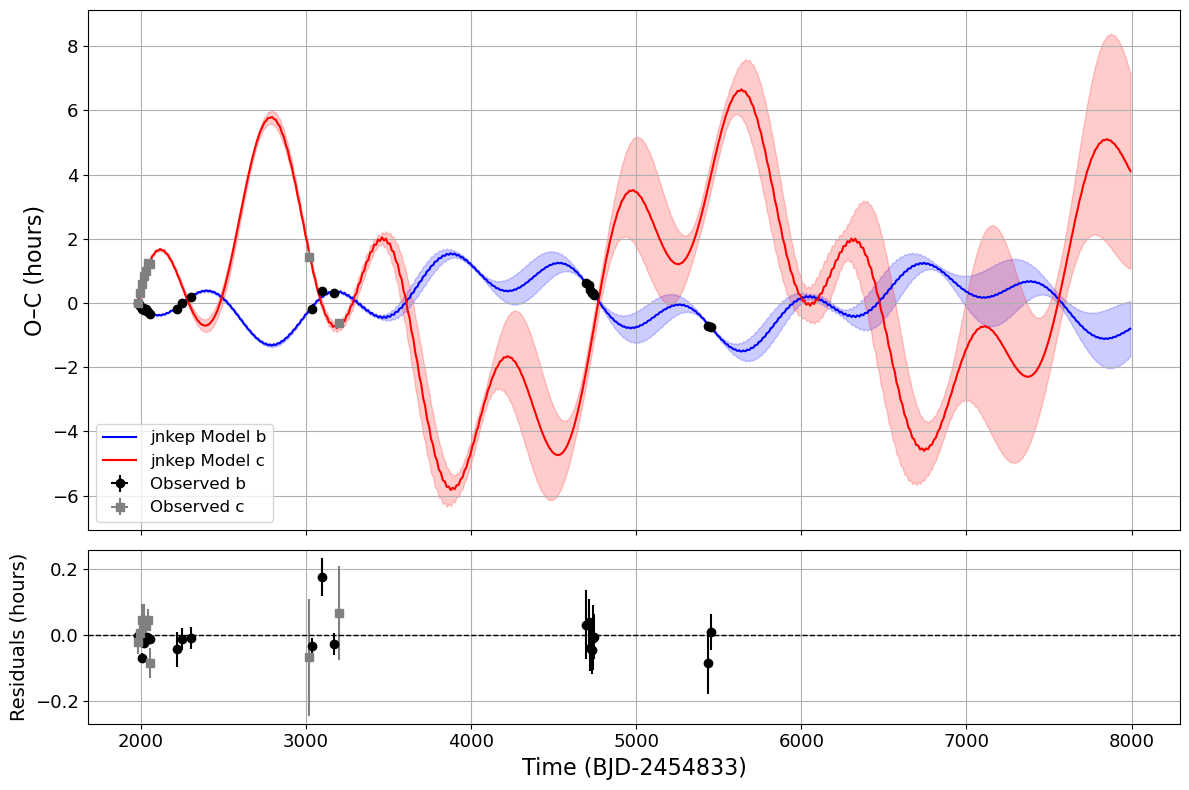

In [19]:
# Set up 2 subplots: main plot and residuals plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

### MAIN PLOT — Flattened Model and Observations
# Planet b model
ax1.plot(t_jnkep_b, flat_jnkep_b*24, label='jnkep Model b', color='b')
ax1.fill_between(t_jnkep_b,
                 (flat_jnkep_b - t_jnkep_err_b)*24,
                 (flat_jnkep_b + t_jnkep_err_b)*24,
                 color='b', alpha=0.2)

# Planet c model
ax1.plot(t_jnkep_c, flat_jnkep_c*24, label='jnkep Model c', color='r')
ax1.fill_between(t_jnkep_c,
                 (flat_jnkep_c - t_jnkep_err_c)*24,
                 (flat_jnkep_c + t_jnkep_err_c)*24,
                 color='r', alpha=0.2)

flat_obs_b = np.array(flat_obs_b)
t_obs_err_b = np.array(t_obs_err_b)
flat_obs_c = np.array(flat_obs_c)
t_obs_err_c = np.array(t_obs_err_c)

# Observed points with error bars
ax1.errorbar(t_obs_b, (flat_obs_b*24), xerr=t_obs_err_b, yerr=(t_obs_err_b*24),
             marker='o', linestyle='none', label='Observed b', color='black')
ax1.errorbar(t_obs_c, (flat_obs_c*24), xerr=t_obs_err_c, yerr=(t_obs_err_c*24),
             marker='s', linestyle='none', label='Observed c', color='grey')

# ax1.set_title('Flattened O–C', fontsize=16)
ax1.set_ylabel('O–C (hours)', fontsize=16)
# ax1.set_xlim(1850, 5500)
ax1.legend(fontsize=12)
ax1.grid(True)

### RESIDUALS PLOT — (Observed - Model)
# Interpolate model at observed points if needed
from scipy.interpolate import interp1d

# Interpolation to match observed points
model_interp_b = interp1d(t_jnkep_b, flat_jnkep_b, bounds_error=False, fill_value="extrapolate")
model_interp_c = interp1d(t_jnkep_c, flat_jnkep_c, bounds_error=False, fill_value="extrapolate")

residuals_b = flat_obs_b - model_interp_b(t_obs_b)
residuals_c = flat_obs_c - model_interp_c(t_obs_c)

# Plot residuals with error bars
ax2.errorbar(t_obs_b, residuals_b*24, xerr=t_obs_err_b, yerr=t_obs_err_b*24,
             marker='o', linestyle='none', color='black')
ax2.errorbar(t_obs_c, residuals_c*24, xerr=t_obs_err_c, yerr=t_obs_err_c*24,
             marker='s', linestyle='none', color='grey')

ax2.axhline(0, color='k', linestyle='--', linewidth=1)
ax2.set_xlabel(f'Time (BJD-{petigura_offset})', fontsize=16)
ax2.set_ylabel('Residuals (hours)', fontsize=14)
# ax2.set_xlim(1850, 5500)
# ax2.legend(fontsize=12)
ax2.grid(True)

ax1.tick_params(axis='both', labelsize=13)
ax2.tick_params(axis='both', labelsize=13)


plt.tight_layout()
plt.show()
